# Experiment 1 — Báo cáo kết quả

Cấu trúc notebook:

1. **Phần thư viện** (các cell code phía trên, có docstring) — định nghĩa toàn bộ hàm đọc dữ liệu,
   dựng bảng, vẽ biểu đồ. Chỉ cần chạy các cell này **một lần mỗi phiên** (Run All phần trên).
2. **Phần chạy report** (cuối notebook) — mỗi lần có kết quả mới, **thêm một cell mới** gọi
   `generate_report("đường/dẫn/tới/outputs/...")`. Mỗi lần gọi tự ghi vào một thư mục con
   `reports/<timestamp>/` riêng bên trong đường dẫn đó — **không bao giờ ghi đè** report cũ, kể cả
   khi gọi lại đúng cùng một đường dẫn.

`generate_report(...)` nhận 1 trong 3 dạng đường dẫn:
- thư mục lá 1 run kiểu mới: `outputs/<dataTAG>/<optimizer>/<run_id>/`
- thư mục lá 1 run kiểu cũ (trước khi tách theo optimizer): `outputs/<dataTAG>/<run_id>/`
- thư mục mức data-fraction: `outputs/<dataTAG>/` — tự gom bản mới nhất của mỗi (optimizer, seed).

Hàm không tự in nhận xét — chỉ hiển thị bảng/hình + trả về `dict` chứa toàn bộ bảng/hình để tự xem
tiếp nếu cần.

## Thư viện dùng chung — chạy 1 lần mỗi phiên

In [1]:
from pathlib import Path
from datetime import datetime
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# Thứ tự hiển thị + màu cố định cho mọi bảng/biểu đồ trong notebook này.
OPT_ORDER = ['AdamW', 'MCSDCA-odLD', 'MCSDCA-udLD']
OPT_COLORS = {'AdamW': '#1f77b4', 'MCSDCA-odLD': '#d62728', 'MCSDCA-udLD': '#2ca02c'}


def _seed_of(name: str) -> int:
    """Suy seed từ tên thư mục run, dạng '<stamp>__seed<seed>[__tag]'."""
    m = re.search(r'seed(\d+)', name)
    return int(m.group(1)) if m else -1


def resolve_run_dirs(path) -> list[Path]:
    """Quy một đường dẫn kết quả về danh sách thư mục 'lá' (mỗi cái có metrics.csv riêng).

    Nhận 1 trong 3 dạng:
      - thư mục lá kiểu mới   outputs/<dataTAG>/<optimizer>/<run_id>/   (1 optimizer/run)
      - thư mục lá kiểu cũ    outputs/<dataTAG>/<run_id>/               (gộp cả 3 optimizer
                                                                          trong 1 metrics.csv,
                                                                          phân biệt bằng cột 'optimizer')
      - thư mục mức data-fraction  outputs/<dataTAG>/  -> gom mọi optimizer con, mỗi
        (optimizer, seed) lấy bản mới nhất theo mtime của metrics.csv.
    """
    path = Path(path)
    if (path / 'metrics.csv').exists():
        return [path]

    two_level = [p.parent for p in path.glob('*/*/metrics.csv')]  # <optimizer>/<run_id>/metrics.csv
    one_level = [p.parent for p in path.glob('*/metrics.csv') if p.parent.name != 'sanity']
    leafs = two_level if two_level else one_level

    best: dict[tuple, tuple[float, Path]] = {}
    for p in leafs:
        group = p.parent.name if two_level else '_all_'  # thư mục optimizer, hoặc gộp chung (layout cũ)
        key = (group, _seed_of(p.name))
        mtime = (p / 'metrics.csv').stat().st_mtime
        if key not in best or mtime > best[key][0]:
            best[key] = (mtime, p)
    return [p for _, p in sorted(best.values(), key=lambda t: t[1].name)]


def find_comparison_agg(path) -> Path | None:
    """Tìm comparison_agg mới nhất để đối chiếu tham khảo (không bắt buộc phải có).
    Bản mới đặt tên có timestamp ngay dưới thư mục data-fraction; bản cũ tên cố định
    nằm trong từng thư mục run."""
    path = Path(path)
    cands = sorted(path.glob('comparison_agg*.csv'), key=lambda p: p.stat().st_mtime)
    if cands:
        return cands[-1]
    cands = sorted(path.glob('*/comparison_agg.csv'), key=lambda p: p.stat().st_mtime)
    return cands[-1] if cands else None

## 1. Nên dùng MSE hay RMSE?

| | MSE | RMSE = √MSE |
|---|---|---|
| Thứ hạng optimizer | — | **y hệt** (biến đổi đơn điệu ⇒ kết luận không đổi) |
| Ý nghĩa | Chính là đại lượng **đang được tối ưu**: loss huấn luyện = `MSE + λ·SIGReg` | Sai số *điển hình*, **cùng đơn vị** với latent đích (norm ≈ 2–14 ở đây) |
| Phát hiện plateau | Phạt outlier nặng ⇒ độ dốc cuối đường **nhạy hơn** | Mượt hơn, ít bị vài batch xấu kéo lệch |
| Khi giá trị trải rộng | val_mse ở đây trải ~0.03 → ~1.0 (hơn 1 bậc) ⇒ vẽ tuyến tính **bẹp** đường tốt | Nén biên độ ⇒ đọc rõ hơn |

**Khuyến nghị**

- **Bảng cuối**: báo cáo *cả hai* — MSE để đối chiếu trực tiếp với loss huấn luyện, RMSE để diễn giải sai số.
- **Biểu đồ hội tụ**: dùng **RMSE trục tuyến tính** *hoặc* **MSE trục log**. Notebook mặc định
  `METRIC='rmse'` + `LOG_Y=True`; đổi `METRIC='mse'` nếu muốn nhìn thẳng giá trị hàm mục tiêu.
- Để đánh giá "đã hội tụ chưa", cứ nhìn **cùng một chỉ số cho cả train và val** — quan trọng là *độ dốc
  đoạn cuối*, không phải giá trị tuyệt đối.

### Đọc metrics.csv + nội suy đường hội tụ

In [2]:
def load_history(run_dirs: list[Path]) -> pd.DataFrame:
    """Gộp metrics.csv của mọi thư mục run đã resolve, gắn cột 'seed' + 'run_dir',
    chỉ giữ các dòng status == 'ok'."""
    frames = []
    for rd in run_dirs:
        df = pd.read_csv(rd / 'metrics.csv')
        df['seed'] = _seed_of(rd.name)
        df['run_dir'] = str(rd)
        frames.append(df)
    if not frames:
        raise FileNotFoundError('Không có metrics.csv nào để nạp.')
    hist = pd.concat(frames, ignore_index=True)
    return hist[hist.get('status', 'ok').fillna('ok') == 'ok'].copy()


def to_metric(x, metric: str):
    """Đổi mảng MSE thô sang 'rmse' (sqrt) hoặc giữ nguyên 'mse'."""
    x = np.asarray(x, dtype=float)
    return np.sqrt(x) if metric == 'rmse' else x


def agg_curve(hist: pd.DataFrame, opt: str, ycol: str, n_grid: int = 80):
    """Nội suy đường của từng seed lên 1 lưới backprop_calls chung.
    Trả về (grid, mean, std, n_seed) ở dạng RAW (chưa qua to_metric), hoặc None nếu thiếu dữ liệu."""
    if ycol not in hist.columns:
        return None
    sub = hist[hist['optimizer'] == opt][['seed', 'backprop_calls', ycol]].dropna()
    if sub.empty:
        return None
    per_seed = sub.groupby('seed')['backprop_calls']
    lo = float(per_seed.min().max())
    hi = float(per_seed.max().min())
    if hi <= lo:
        lo, hi = float(sub['backprop_calls'].min()), float(sub['backprop_calls'].max())
    grid = np.linspace(lo, hi, n_grid)
    stacks = []
    for _, g in sub.groupby('seed'):
        g = g.sort_values('backprop_calls')
        stacks.append(np.interp(grid, g['backprop_calls'], g[ycol]))
    Y = np.vstack(stacks)
    return grid, Y.mean(0), Y.std(0), Y.shape[0]

### Bảng kết quả cuối cùng

Tính thẳng từ dòng cuối (`backprop_calls` lớn nhất) của mỗi `(optimizer, seed)` trong `hist` —
không phụ thuộc `comparison.csv`, nên vẫn đúng cả khi các optimizer đến từ những lần chạy khác nhau
(ví dụ chỉ chạy lại riêng MCSDCA-odLD sau khi đổi tham số).

In [3]:
MSE_BASES = ['train_mse', 'val_mse', 'rollout_mse_1', 'rollout_mse_3', 'rollout_mse_5']


def build_final_table(hist: pd.DataFrame, metric: str, opt_order: list[str] = OPT_ORDER) -> pd.DataFrame:
    """Dòng cuối mỗi (optimizer, seed) -> gộp mean ± std theo optimizer."""
    last = hist.sort_values('backprop_calls').groupby(['optimizer', 'seed']).tail(1)
    recs = []
    for opt in [o for o in opt_order if o in set(last['optimizer'])]:
        g = last[last['optimizer'] == opt]
        rec = {'optimizer': opt, 'n_seeds': int(g['seed'].nunique()),
               'backprop_calls': int(g['backprop_calls'].max())}
        for base in MSE_BASES:
            if base not in g.columns:
                continue
            v = to_metric(g[base].to_numpy(), metric)
            stem = base.replace('_mse', '') or base  # train_mse->train, rollout_mse_1->rollout_1
            rec[f'{stem}_{metric}_mean'] = float(np.mean(v))
            rec[f'{stem}_{metric}_std'] = float(np.std(v, ddof=0))
        if 'train_val_gap' in g.columns:
            rec['train_val_gap_mean'] = float(g['train_val_gap'].mean())
        recs.append(rec)
    return pd.DataFrame(recs).sort_values(f'val_{metric}_mean').reset_index(drop=True)


def pretty_table(final_tbl: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Bảng gọn 'mean ± std' để dán thẳng vào báo cáo, kèm cột MSE/RMSE tham chiếu của val."""
    metric_label = metric.upper()

    def pm(mean, std, nd=5):
        return f'{mean:.{nd}f} ± {std:.{nd}f}'

    cols = {
        'optimizer': final_tbl['optimizer'],
        'seeds': final_tbl['n_seeds'],
        'backprop_calls': final_tbl['backprop_calls'],
        f'train {metric_label}': [pm(m, s) for m, s in zip(final_tbl[f'train_{metric}_mean'], final_tbl[f'train_{metric}_std'])],
        f'val {metric_label}': [pm(m, s) for m, s in zip(final_tbl[f'val_{metric}_mean'], final_tbl[f'val_{metric}_std'])],
    }
    if 'train_val_gap_mean' in final_tbl.columns:
        cols['train-val gap'] = [f'{v:.2e}' for v in final_tbl['train_val_gap_mean']]
    if f'rollout_5_{metric}_mean' in final_tbl.columns:
        cols[f'rollout-5 {metric_label}'] = [
            pm(m, s) for m, s in zip(final_tbl[f'rollout_5_{metric}_mean'], final_tbl[f'rollout_5_{metric}_std'])
        ]
    return pd.DataFrame(cols)

### Biểu đồ đường hội tụ theo ngân sách backprop

- **Trục ngang**: `backprop_calls` — số lần lan truyền ngược đã tiêu.
- **Trục đứng**: sai số dự đoán theo `metric` (`rmse`/`mse`).
- **Nét liền = val**, **nét đứt = train**; dải mờ = ±1 std trên các seed.
- Đường *đi ngang* ở đoạn cuối ⇒ đã hết cải thiện trong ngân sách này.

In [4]:
def plot_convergence(hist: pd.DataFrame, present: list[str], metric: str, log_y: bool,
                      title: str, save_path: Path | None = None):
    """Đường hội tụ chính: train (nét đứt) + val (nét liền) theo backprop_calls, mọi optimizer."""
    metric_label = metric.upper()
    n_seeds = hist['seed'].nunique()
    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    for opt in present:
        for split, ycol, ls in [('train', 'train_mse', '--'), ('val', 'val_mse', '-')]:
            res = agg_curve(hist, opt, ycol)
            if res is None:
                continue
            x, mean, std, ns = res
            mean_m = to_metric(mean, metric)
            ax.plot(x, mean_m, ls=ls, lw=2, color=OPT_COLORS.get(opt), label=f'{opt} · {split}')
            if ns > 1:
                band = to_metric(np.clip(mean + std, 0, None), metric) - mean_m
                ax.fill_between(x, mean_m - band, mean_m + band, color=OPT_COLORS.get(opt), alpha=0.15, lw=0)
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel('Ngân sách lan truyền ngược  (backprop_calls)')
    ax.set_ylabel(f'{metric_label} dự đoán 1 bước')
    ax.set_title(f'Đường hội tụ — {title}  ({metric_label}, {n_seeds} seed)')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(ncol=3, fontsize=8, loc='upper right')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()
    return fig

### Đường hội tụ cho 1 cột bất kỳ (vd rollout-5)

Hàm tổng quát, dùng lại được cho mọi cột số trong `metrics.csv` (không chỉ rollout-5).

In [5]:
def plot_metric_curve(hist: pd.DataFrame, present: list[str], ycol: str, ylabel: str, metric: str,
                       log_y: bool, title: str, save_path: Path | None = None):
    """Đường hội tụ cho MỘT cột (vd rollout_mse_5) — bản tổng quát của plot_convergence."""
    if ycol not in hist.columns or not hist[ycol].notna().any():
        print(f'Không có cột {ycol}.')
        return None
    metric_label = metric.upper()
    n_seeds = hist['seed'].nunique()
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    for opt in present:
        res = agg_curve(hist, opt, ycol)
        if res is None:
            continue
        x, mean, std, ns = res
        mean_m = to_metric(mean, metric)
        ax.plot(x, mean_m, lw=2, color=OPT_COLORS.get(opt), label=opt)
        if ns > 1:
            band = to_metric(np.clip(mean + std, 0, None), metric) - mean_m
            ax.fill_between(x, mean_m - band, mean_m + band, color=OPT_COLORS.get(opt), alpha=0.15, lw=0)
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel('Ngân sách lan truyền ngược  (backprop_calls)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} ({metric_label}, {n_seeds} seed)')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()
    return fig

## 3c. Chẩn đoán sụp đổ biểu diễn — encoder hay predictor?

Mục tiêu LeWM **không** stop-gradient trên target, nên SIGReg là lực chống sụp đổ duy nhất.
Các cột `col_*` (one-step, trên val) tách vị trí sụp đổ:

| Cột | Ý nghĩa | Sụp khi |
|---|---|---|
| `col_enc_emb_var_mean` | phương sai trung bình đầu ra encoder | → 0 |
| `col_enc_dead_dim_frac` | tỉ lệ chiều encoder có var < 1e-4 | → 1 |
| `col_enc_emb_norm_mean` | ‖emb‖ trung bình | → nhỏ |
| `col_pred_target_var_ratio` | var(pred) / var(target), cắt trần ở 10 | ≪ 1 ⇒ **predictor sụp** |
| `col_pred_target_norm_ratio` | ‖pred‖ / ‖target‖, cắt trần ở 10 | ≪ 1 |

**Đọc:** `enc_*` thấp + `dead_dim_frac` cao ⇒ **encoder sụp**. `enc_*` khỏe nhưng
`pred_target_var_ratio` ≪ 1 ⇒ **predictor sụp**. Cả hai thấp ⇒ encoder kéo theo.

In [6]:
COLLAPSE_PANELS = [
    ('col_enc_emb_var_mean',       'var(emb) encoder',           True),
    ('col_enc_dead_dim_frac',      'tỉ lệ chiều encoder "chết"',  False),
    ('col_pred_target_var_ratio',  'var(pred) / var(target)',     False),
    ('col_pred_target_norm_ratio', '‖pred‖ / ‖target‖',           False),
]


def plot_collapse_panels(hist: pd.DataFrame, present: list[str], title: str, save_path: Path | None = None):
    """4 panel chẩn đoán sụp đổ biểu diễn (encoder vs predictor) + bảng giá trị cuối theo optimizer.
    Trả về (fig, bảng_cuối) — (None, None) nếu metrics.csv chưa có cột col_*."""
    avail = [p for p in COLLAPSE_PANELS if p[0] in hist.columns]
    if not avail:
        print('metrics.csv chưa có cột col_* — chạy lại bằng src/run_experiment1.py bản mới.')
        return None, None
    n_seeds = hist['seed'].nunique()
    fig, axes = plt.subplots(1, len(avail), figsize=(4.6 * len(avail), 4.2), squeeze=False)
    for ax, (col, ptitle, logy) in zip(axes[0], avail):
        for opt in present:
            res = agg_curve(hist, opt, col)
            if res is None:
                continue
            x, mean, std, ns = res
            ax.plot(x, mean, lw=2, color=OPT_COLORS.get(opt), label=opt)
            if ns > 1:
                ax.fill_between(x, mean - std, mean + std, color=OPT_COLORS.get(opt), alpha=0.15, lw=0)
        if 'ratio' in col:
            ax.axhline(1.0, color='0.4', ls=':', lw=1)  # mốc lành mạnh
        if logy:
            ax.set_yscale('log')
        ax.set_title(ptitle, fontsize=10)
        ax.set_xlabel('backprop_calls')
        ax.grid(True, which='both', alpha=0.3)
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f'Chẩn đoán sụp đổ biểu diễn — {title} ({n_seeds} seed)', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    last = hist.sort_values('backprop_calls').groupby(['optimizer', 'seed']).tail(1)
    cols = [c for c, _, _ in avail] + ['col_pred_var_mean', 'col_target_var_mean', 'col_enc_emb_norm_mean']
    cols = [c for c in cols if c in last.columns]
    summary = last.groupby('optimizer')[cols].mean().reindex(present)
    return fig, summary

## 4. Chẩn đoán plateau — "đường đã đi ngang chưa?"

Với mỗi optimizer × {train, val}, xét đoạn cuối chiếm `PLATEAU_LAST_FRAC` bề rộng ngân sách và tính:

- **rel_drop_tail**: `(y_đầu_đoạn − y_cuối_đoạn) / y_đầu_đoạn` — dương = *vẫn còn giảm*.
- **rel_span_tail**: `(max − min) / mean` trên đoạn cuối — lớn = *còn dao động mạnh*.
- **slope_per_1k**: độ dốc hồi quy tuyến tính (đơn vị `METRIC` trên mỗi 1000 backprop).
- **verdict**:
  - `đã đi ngang` nếu `|rel_drop_tail| < PLATEAU_REL_TOL` **và** `rel_span_tail < 2·PLATEAU_REL_TOL`;
  - `chưa hội tụ (còn giảm)` nếu `rel_drop_tail ≥ PLATEAU_REL_TOL`;
  - `còn dao động` nếu không giảm rõ nhưng biên độ đoạn cuối lớn.

In [7]:
def _plateau_row(hist, opt, split, ycol, metric, last_frac, rel_tol):
    res = agg_curve(hist, opt, ycol)
    if res is None:
        return None
    x, mean, _, _ = res
    y = to_metric(mean, metric)
    span = x.max() - x.min()
    mask = x >= (x.max() - last_frac * span) if span > 0 else np.ones_like(x, bool)
    xt, yt = x[mask], y[mask]
    y0, y1 = float(yt[0]), float(yt[-1])
    rel_drop = (y0 - y1) / abs(y0) if y0 else np.nan
    rel_span = (yt.max() - yt.min()) / abs(yt.mean()) if yt.mean() else np.nan
    slope = np.polyfit(xt, yt, 1)[0] if len(xt) > 1 else 0.0
    if abs(rel_drop) < rel_tol and rel_span < 2 * rel_tol:
        verdict = 'đã đi ngang'
    elif rel_drop >= rel_tol:
        verdict = 'chưa hội tụ (còn giảm)'
    else:
        verdict = 'còn dao động'
    return {'optimizer': opt, 'split': split, f'{metric.upper()}_cuối': round(y1, 6),
            'rel_drop_tail': round(float(rel_drop), 4), 'rel_span_tail': round(float(rel_span), 4),
            'slope_per_1k': f'{slope * 1000:.2e}', 'verdict': verdict}


def build_plateau_table(hist: pd.DataFrame, present: list[str], metric: str,
                         last_frac: float, rel_tol: float) -> pd.DataFrame:
    """Với mỗi optimizer x {train, val}: đoạn cuối `last_frac` bề rộng ngân sách đã đi ngang chưa?
    rel_drop_tail dương = vẫn còn giảm; rel_span_tail lớn = còn dao động (xem docstring _plateau_row)."""
    rows = [_plateau_row(hist, opt, split, ycol, metric, last_frac, rel_tol)
            for opt in present for split, ycol in [('train', 'train_mse'), ('val', 'val_mse')]]
    return pd.DataFrame([r for r in rows if r])

### Hàm điều phối chính — `generate_report`

Gom toàn bộ các bước trên: resolve đường dẫn → nạp `hist` → bảng cuối → biểu đồ hội tụ
(chính + rollout-5) → chẩn đoán sụp đổ → bảng plateau. Luôn ghi vào một thư mục con
`reports/<timestamp-lúc-gọi>/` riêng bên trong `results_dir`, nên gọi lại bao nhiêu lần, với
đường dẫn nào, cũng không đè lên report trước đó.

In [8]:
def generate_report(
    results_dir,
    *,
    metric: str = 'rmse',
    log_y: bool = True,
    plateau_last_frac: float = 0.30,
    plateau_rel_tol: float = 0.05,
    opt_order: list[str] = OPT_ORDER,
    save: bool = True,
) -> dict:
    """Tạo đầy đủ report cho 1 đường dẫn kết quả (xem resolve_run_dirs cho các dạng đường
    dẫn được chấp nhận). Không tự in nhận xét — chỉ hiển thị bảng/hình.

    Không bao giờ ghi đè report cũ: mỗi lần gọi (kể cả cùng results_dir) ghi vào một
    thư mục con reports/<timestamp-lúc-gọi>/ riêng bên trong results_dir.
    """
    results_dir = Path(results_dir)
    if not results_dir.is_absolute():
        results_dir = (REPO_ROOT / results_dir).resolve()
    assert results_dir.exists(), f'Không tồn tại: {results_dir}'

    run_dirs = resolve_run_dirs(results_dir)
    assert run_dirs, f'Không có metrics.csv trong {results_dir} hay các thư mục con'
    hist = load_history(run_dirs)
    metric = metric.lower()
    present = [o for o in opt_order if o in set(hist['optimizer'])]

    report_dir = results_dir / 'reports' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')[:-3]
    if save:
        report_dir.mkdir(parents=True, exist_ok=True)

    print('results_dir =', results_dir)
    print('run_dirs    =', [p.name for p in run_dirs])
    print('optimizers  =', present, '| seeds =', sorted(hist['seed'].unique()))
    print('report_dir  =', report_dir if save else '(save=False, không ghi file)')

    final_tbl = build_final_table(hist, metric, opt_order)
    pretty = pretty_table(final_tbl, metric)
    display(final_tbl)
    display(pretty)

    agg_ref_path = find_comparison_agg(results_dir)
    if agg_ref_path is not None:
        print('Đối chiếu với comparison_agg do pipeline sinh ra:', agg_ref_path)
        display(pd.read_csv(agg_ref_path))

    fig_main = plot_convergence(
        hist, present, metric, log_y, results_dir.name,
        save_path=(report_dir / 'report_convergence.png') if save else None,
    )
    fig_rollout5 = plot_metric_curve(
        hist, present, 'rollout_mse_5', f'{metric.upper()} rollout-5 (val)', metric, log_y,
        f'Hội tụ rollout-5 — {results_dir.name}',
        save_path=(report_dir / 'report_convergence_rollout5.png') if save else None,
    )
    fig_collapse, collapse_summary = plot_collapse_panels(
        hist, present, results_dir.name,
        save_path=(report_dir / 'report_collapse.png') if save else None,
    )
    if collapse_summary is not None:
        display(collapse_summary)

    plateau_tbl = build_plateau_table(hist, present, metric, plateau_last_frac, plateau_rel_tol)
    display(plateau_tbl)

    if save:
        final_tbl.to_csv(report_dir / 'report_final_table.csv', index=False)
        plateau_tbl.to_csv(report_dir / 'report_plateau.csv', index=False)
        print('Đã lưu report_* vào:', report_dir)

    return {
        'results_dir': results_dir, 'run_dirs': run_dirs, 'report_dir': report_dir,
        'hist': hist, 'present': present, 'metric': metric,
        'final_table': final_tbl, 'pretty_table': pretty, 'plateau_table': plateau_tbl,
        'collapse_summary': collapse_summary,
        'figures': {'convergence': fig_main, 'rollout5': fig_rollout5, 'collapse': fig_collapse},
    }

## Chạy report cho từng lần train

Mỗi khi có kết quả mới: **thêm một cell mới** ở dưới, đổi đường dẫn, chạy. Không cần sửa gì ở
phần thư viện phía trên.

results_dir = D:\DCA\MCSDCA\outputs\data1
run_dirs    = ['20260912_084204_119__seed3072__baseline_check_1', '20260912_084204_119__seed3072__baseline_check_1', '20260912_084204_119__seed3072__baseline_check_1']
optimizers  = ['AdamW', 'MCSDCA-odLD', 'MCSDCA-udLD'] | seeds = [np.int64(3072)]
report_dir  = D:\DCA\MCSDCA\outputs\data1\reports\20260912_092813_656


,optimizer,n_seeds,backprop_calls,train_rmse_mean,train_rmse_std,val_rmse_mean,val_rmse_std,rollout_1_rmse_mean,rollout_1_rmse_std,rollout_3_rmse_mean,rollout_3_rmse_std,rollout_5_rmse_mean,rollout_5_rmse_std,train_val_gap_mean
0,AdamW,1,2380,0.409623,0.0,0.407060,0.0,0.416840,0.0,0.589833,0.0,0.711291,0.0,-0.002094
1,MCSDCA-odLD,1,702,1.612227,0.0,1.615805,0.0,1.639349,0.0,1.631709,0.0,1.616737,0.0,0.011550
2,MCSDCA-udLD,1,702,4.046662,0.0,4.054648,0.0,4.046839,0.0,4.202718,0.0,4.286928,0.0,0.064697


,optimizer,seeds,backprop_calls,train RMSE,val RMSE,train-val gap,rollout-5 RMSE
0,AdamW,1,2380,0.40962 ± 0.00000,0.40706 ± 0.00000,-2.09e-03,0.71129 ± 0.00000
1,MCSDCA-odLD,1,702,1.61223 ± 0.00000,1.61581 ± 0.00000,1.16e-02,1.61674 ± 0.00000
2,MCSDCA-udLD,1,702,4.04666 ± 0.00000,4.05465 ± 0.00000,6.47e-02,4.28693 ± 0.00000


Đối chiếu với comparison_agg do pipeline sinh ra: D:\DCA\MCSDCA\outputs\data1\comparison_agg_20260912_090612_330.csv


,optimizer,data_fraction,n_seeds_ok,val_mse_mean,val_mse_std,train_mse_mean,train_mse_std,train_val_gap_mean,train_val_gap_std,rollout_mse_1_mean,...,col_enc_emb_var_mean_mean,col_enc_emb_var_mean_std,col_enc_dead_dim_frac_mean,col_enc_dead_dim_frac_std,col_pred_target_var_ratio_mean,col_pred_target_var_ratio_std,col_pred_target_norm_ratio_mean,col_pred_target_norm_ratio_std,roll_pred_target_var_ratio_mean,roll_pred_target_var_ratio_std
0,AdamW,0.01,1,0.165698,0.0,0.167791,0.0,-0.002094,0.0,0.173755,...,0.690915,0.0,0.0,0.0,0.839381,0.0,0.891199,0.0,0.905222,0.0
1,MCSDCA-odLD,0.01,1,2.610826,0.0,2.599276,0.0,0.011550,0.0,2.687464,...,0.354594,0.0,0.0,0.0,0.113535,0.0,0.255634,0.0,0.101552,0.0
2,MCSDCA-udLD,0.01,1,16.440170,0.0,16.375474,0.0,0.064697,0.0,16.376904,...,0.382653,0.0,0.0,0.0,0.044779,0.0,0.190821,0.0,0.180598,0.0


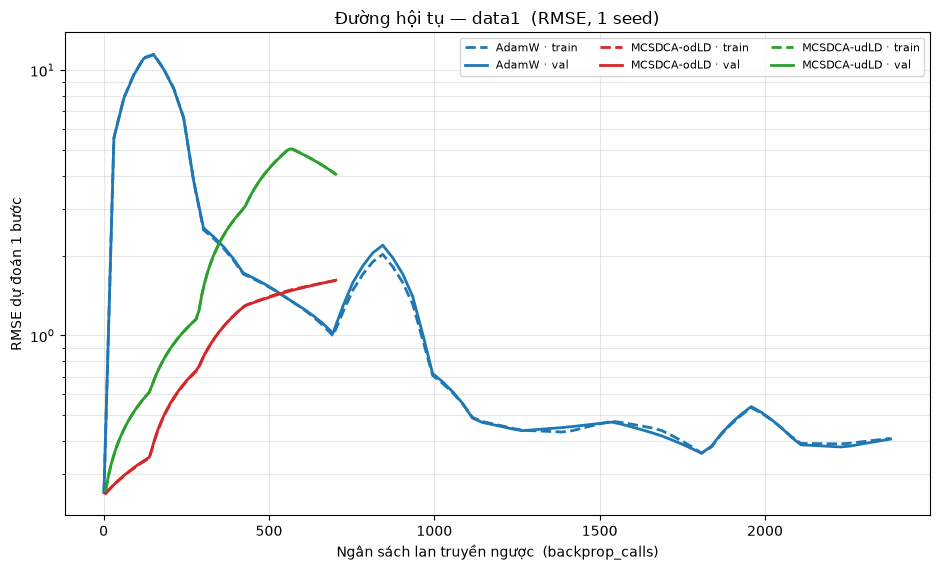

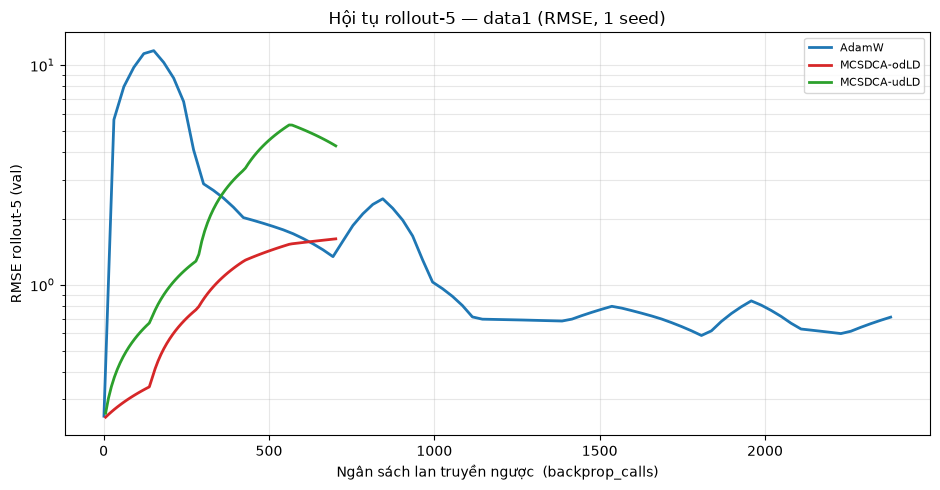

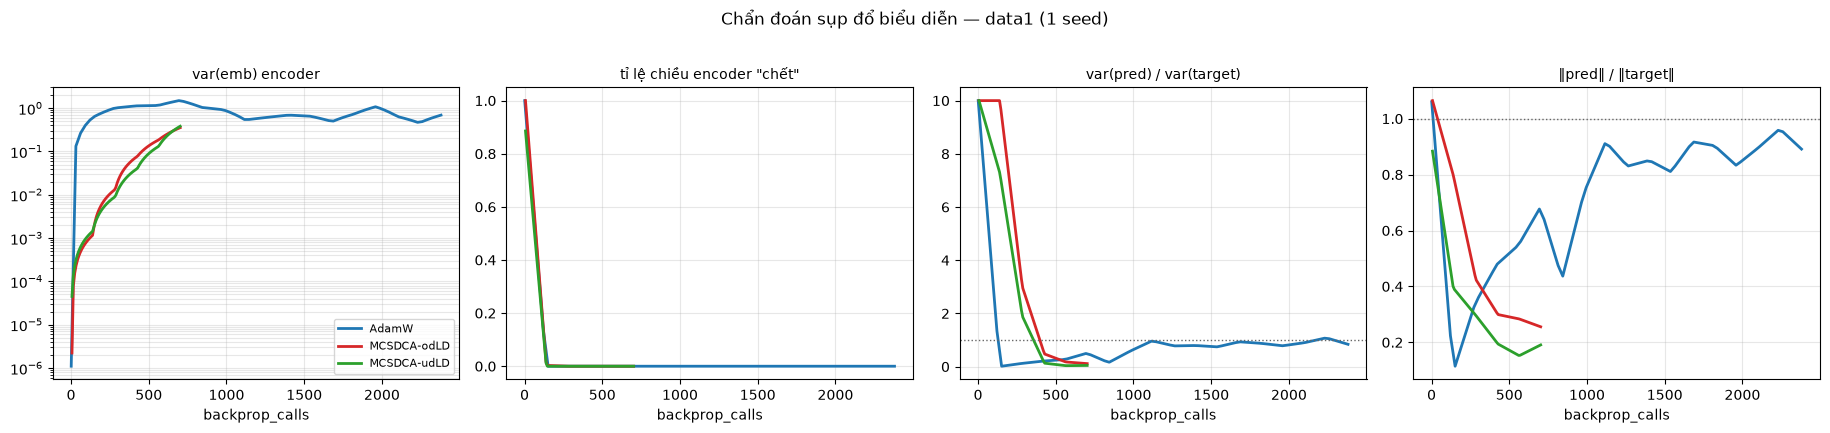

,col_enc_emb_var_mean,col_enc_dead_dim_frac,col_pred_target_var_ratio,col_pred_target_norm_ratio,col_pred_var_mean,col_target_var_mean,col_enc_emb_norm_mean
optimizer,,,,,,,
AdamW,0.690915,0.0,0.839381,0.891199,0.577921,0.690982,13.312435
MCSDCA-odLD,0.354594,0.0,0.113535,0.255634,0.034979,0.311152,22.270370
MCSDCA-udLD,0.382653,0.0,0.044779,0.190821,0.015172,0.338919,65.213616


,optimizer,split,RMSE_cuối,rel_drop_tail,rel_span_tail,slope_per_1k,verdict
0,AdamW,train,0.409623,0.0660,0.4138,-4.17e-02,chưa hội tụ (còn giảm)
1,AdamW,val,0.407060,0.0274,0.4305,-4.13e-02,còn dao động
2,MCSDCA-odLD,train,1.612227,-0.1530,0.1413,1.03e+00,còn dao động
3,MCSDCA-odLD,val,1.615805,-0.1616,0.1490,1.10e+00,còn dao động
4,MCSDCA-udLD,train,4.046662,0.0476,0.2196,-2.37e+00,còn dao động
5,MCSDCA-udLD,val,4.054648,0.0439,0.2148,-2.28e+00,còn dao động


Đã lưu report_* vào: D:\DCA\MCSDCA\outputs\data1\reports\20260912_092813_656


In [9]:
r1 = generate_report(r"D:\DCA\MCSDCA\outputs\data1")